---
### 3-2. ML 프로세스 이해 (w/code)
- wine quality dataset 
---

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [2]:
# data loading 
df = pd.read_csv('data/winequality-red.csv', sep=';')
print(df.shape) 
df.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


<Axes: xlabel='quality', ylabel='count'>

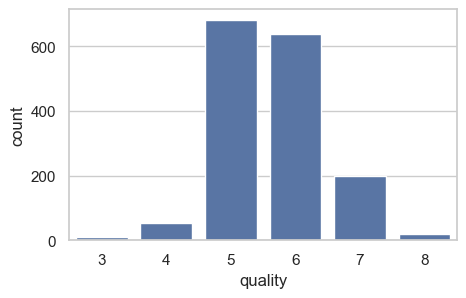

In [3]:
print(df['quality'].value_counts())

plt.figure(figsize=(5,3))
sns.countplot(data=df, x='quality')

#### 1. 문제의 정의 
- 화학적 성분 변수들을 사용하여, 와인의 품질등급을 예측하는 것이 목적
- target 변수는 quality이며, 여러개의 등급으로 구분하는 "분류"의 문제이다

In [4]:
# 변수타입 및 결측치 
print(df.info()) 
print('-' * 100)
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None
----------------------------------------------------------------------------------------------------
fixed acidity       

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


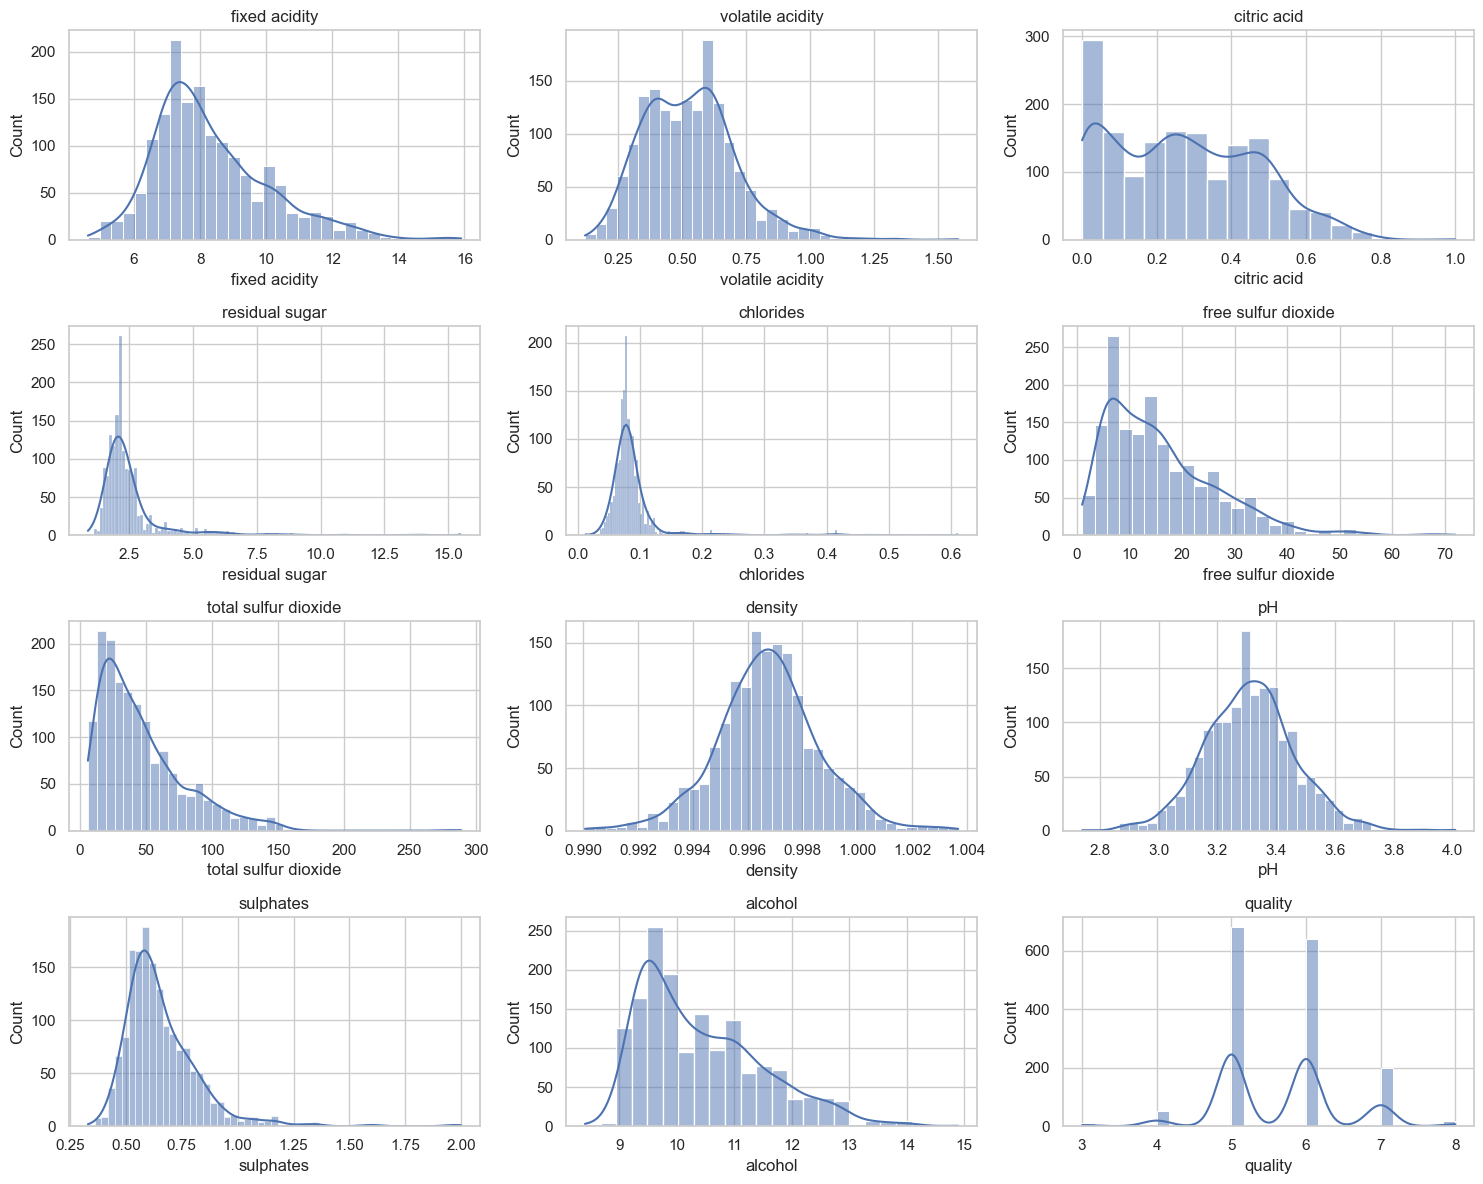

In [5]:
# 변수분포
display(df.describe())

num_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(4, 3, figsize=(15,12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

#### 2. EDA 
- 타겟인 quality를 제외하고 모든 변수들이 수치형이다. 
- 결측치는 존재하지 않느다. 
- 수치형 변수들의 단위가 상이하며, 일부 변수들에는 극단치가 포함되어 있다. 

In [6]:
#!pip install scikit-learn

In [7]:
from sklearn.model_selection import train_test_split

# target 정의 
y = df['quality']
X = df.drop('quality', axis=1)
print('데이터 분할 전 : ', X.shape, y.shape)

# 훈련/검증 데이터 분리 
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('데이터 분할 후 : ', X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

데이터 분할 전 :  (1599, 11) (1599,)
데이터 분할 후 :  (1279, 11) (320, 11) (1279,) (320,)


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

#### 3~4. 데이터 전처리, 학습/검증 데이터 분할 
- 타겟변수 quality를 y로 정의하고, 나머지 변수들을 X로 정의 
- 데이터를 학습용:훈련용 = 8:2로 분할하였다. 이때 와인등급이 등급별로 불균형하므로 y의 분포를 기준으로 배분하였다. 
- 변수들을 표준화하였다.

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### 5. 모델 선정 및 학습 
- 다중분류 문제에 해당 --> 랜덤포레스트 분류 모델 선택 
- 학습용 데이터(X_train, y_tran)에 대해 모델 훈련 

In [10]:
from sklearn.metrics import accuracy_score, f1_score
y_pred = rf.predict(X_valid)

print("모델 정확도 = ", accuracy_score(y_valid, y_pred))
print("F1 score = ", f1_score(y_valid, y_pred, average='macro'))

모델 정확도 =  0.68125
F1 score =  0.4094768334380015


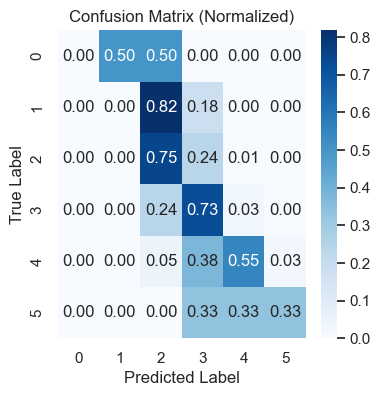

In [19]:
# confusion matrix 
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, y_pred)
cm_ratio = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(4,4))
sns.heatmap(cm_ratio, 
            annot=True, 
            fmt='.2f', 
            cmap='Blues',
            )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Normalized)")
plt.show()

#### 6. 성능평가 
- 앞서 학습한 모델에 검증용 데이터를 투입하여, 예측성능을 측정하였다. 
- 측정에는 분류모델의 대표적인 평가지표인 정확도와 F1 점수를 사용하였다. 

---

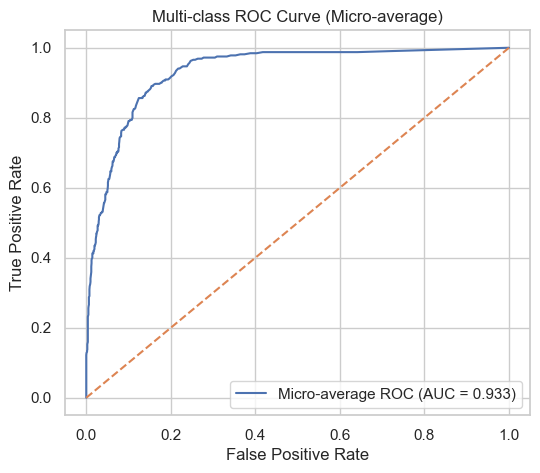

In [12]:
# 시각화 
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_score = rf.predict_proba(X_valid)
classes = np.unique(y_train)
y_valid_bin = label_binarize(y_valid, classes=classes)

fpr, tpr, _ = roc_curve(y_valid_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Micro-average ROC (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve (Micro-average)")
plt.legend()
plt.show()

---

In [13]:
# encoding, scaling example

data = {
    "age": [25, 45, 35, 50, 23, 40, 60, 48],
    "income": [3000, 8000, 5000, 9000, 2800, 7000, 10000, 8500],
    "gender": ["M", "F", "F", "M", "M", "F", "M", "F"],
    "city": ["Seoul", "Busan", "Seoul", "Daegu", "Busan", "Seoul", "Daegu", "Seoul"],
    "loan_approved": [0, 1, 0, 1, 0, 1, 1, 1]
}

df = pd.DataFrame(data)
df

,age,income,gender,city,loan_approved
0,25,3000,M,Seoul,0
1,45,8000,F,Busan,1
2,35,5000,F,Seoul,0
3,50,9000,M,Daegu,1
4,23,2800,M,Busan,0
5,40,7000,F,Seoul,1
6,60,10000,M,Daegu,1
7,48,8500,F,Seoul,1


In [14]:
# One-Hot encoding 
df = pd.get_dummies(df, drop_first=True, dtype=int)
df

,age,income,loan_approved,gender_M,city_Daegu,city_Seoul
0,25,3000,0,1,0,1
1,45,8000,1,0,0,0
2,35,5000,0,0,0,1
3,50,9000,1,1,1,0
4,23,2800,0,1,0,0
5,40,7000,1,0,0,1
6,60,10000,1,1,1,0
7,48,8500,1,0,0,1


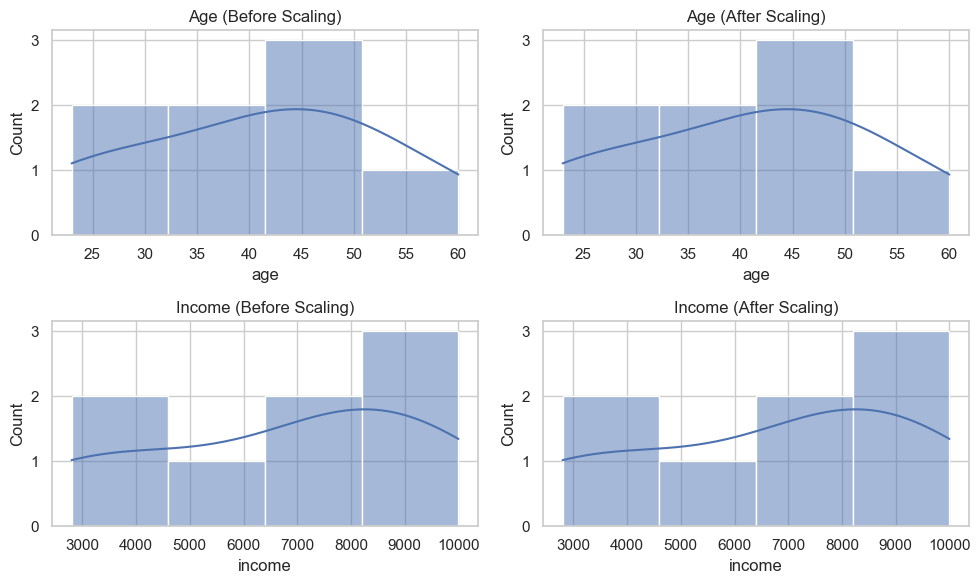

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# age - before
sns.histplot(df['age'], kde=True, ax=axes[0,0])
axes[0,0].set_title("Age (Before Scaling)")

# age - after
sns.histplot(df['age'], kde=True, ax=axes[0,1])
axes[0,1].set_title("Age (After Scaling)")

# income - before
sns.histplot(df['income'], kde=True, ax=axes[1,0])
axes[1,0].set_title("Income (Before Scaling)")

# income - after
sns.histplot(df['income'], kde=True, ax=axes[1,1])
axes[1,1].set_title("Income (After Scaling)")

plt.tight_layout()
plt.show()